In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
import numpy as np

ERROR! Session/line number was not unique in database. History logging moved to new session 212


In [2]:
data = pd.read_csv('C:\\Users\\Администратор\\Documents\\study\\APS\\notebooks\\df_model_aps_data.csv')
# data = pd.read_csv('/content/df_model_aps_data.csv')
# data.columns.tolist()

In [ ]:
# to track the number of columns after each drop
print(data.shape[1])
data = data.drop(columns=data.columns[data.columns.str.startswith('reoccurred')], errors='ignore')
print(data.shape[1])
data = data.drop(columns=['time_since_first_open', 'main_id', 'first_open_date', 'duration'], errors='ignore') # dropping the columns that are not needed for modeling
print(data.shape[1])

97
93
89


### Feature Engineering (creating the target)

In [4]:
# Make a copy of the original data to preserve it
df = data.copy()

# 1. Extract person-level ID
df['person_id'] = df['id'].str.split('-').str[0]

# Ensure date columns are datetime objects
df['open_date'] = pd.to_datetime(df['open_date'])
df['closed_date'] = pd.to_datetime(df['closed_date'])

# 2. Sort cases within each person by open_date
df = df.sort_values(by=['person_id', 'open_date']).reset_index(drop=True)

# 3. Create case_order
df['case_order'] = df.groupby('person_id').cumcount() + 1

# 4. Define t0 = first open_date for that person
df['t0'] = df.groupby('person_id')['open_date'].transform('min')

# 5 & 6. Create stop_time and event_next
# Get the next case's open_date
df['next_open_date'] = df.groupby('person_id')['open_date'].shift(-1)

# event_next: 1 if another APS case occurs, 0 otherwise
df['event_next'] = df['next_open_date'].notna().astype(int)

# Define end of observation period as 3 years after t0
df['end_of_obs'] = df['t0'] + pd.DateOffset(years=3)

# Calculate stop_time (in days)
df['stop_time'] = np.where(
    df['event_next'] == 1,
    (df['next_open_date'] - df['t0']).dt.days,
    (df['end_of_obs'] - df['t0']).dt.days
)

# 7. Keep required rows and original case-level predictors
# cols_to_keep = [
#     'person_id', 'case_order', 'stop_time', 'event_next',
#     'id', 'open_date', 'closed_date', 'number_of_days_open'
# ]
survival_df = df.copy()

# 8. Output the final dataset sorted by person ID and case_order
survival_df = survival_df.sort_values(['person_id', 'case_order']).reset_index(drop=True)

survival_df.head(10)

,id,referral_date,open_date,number_of_days_open,disposition_status_description,prior_aps_history_before_2022,age_at_time_of_referral,gender,race,marital_status_description,...,perpetrator_intial_risk_mental_emotional_health_control_over_client,total_case_count,closed_date,person_id,case_order,t0,next_open_date,event_next,end_of_obs,stop_time
0,987679398-2,2024-09-04,2024-09-04,15.0,CLOSED,Y,80.0,M,Caucasian/White,Single-Never Married,...,1,2,2024-09-19,987679398,1,2024-09-04,NaT,0,2027-09-04,1095.0
1,987679482-1,2022-03-01,2022-03-01,45.0,CLOSED,N,57.0,M,Caucasian/White,Married-Living Together,...,2,10,2022-04-15,987679482,1,2022-03-01,2023-02-13,1,2025-03-01,349.0
2,987679482-3,2023-02-13,2023-02-13,59.0,CLOSED,N,58.0,M,Caucasian/White,Single-Never Married,...,1,10,2023-04-13,987679482,2,2022-03-01,2024-10-09,1,2025-03-01,953.0
3,987679482-7,2024-10-09,2024-10-09,29.0,CLOSED,N,NaN,M,Caucasian/White,Married-Living Together,...,1,10,2024-11-07,987679482,3,2022-03-01,NaT,0,2025-03-01,1096.0
4,987679506-1,2024-10-31,2024-10-31,50.0,CLOSED,N,56.0,F,Caucasian/White,Married-Living Together,...,2,1,2024-12-20,987679506,1,2024-10-31,NaT,0,2027-10-31,1095.0
5,987679558-1,2023-06-08,2023-06-08,13.0,CLOSED,N,69.0,M,Caucasian/White,NaN,...,1,1,2023-06-21,987679558,1,2023-06-08,NaT,0,2026-06-08,1096.0
6,987679646-1,2022-12-14,2022-12-14,40.0,CLOSED,Y,58.0,F,Caucasian/White,Single-Never Married,...,1,2,2023-01-23,987679646,1,2022-12-14,2023-03-31,1,2025-12-14,107.0
7,987679646-2,2023-03-31,2023-03-31,27.0,CLOSED,Y,58.0,F,Unable to determine,Single-Never Married,...,1,2,2023-04-27,987679646,2,2022-12-14,NaT,0,2025-12-14,1096.0
8,987679670-1,2022-01-11,2022-01-11,30.0,CLOSED,Y,81.0,F,Caucasian/White,Widowed,...,1,2,2022-02-10,987679670,1,2022-01-11,2022-02-16,1,2025-01-11,36.0
9,987679670-2,2022-02-16,2022-02-16,26.0,CLOSED,Y,81.0,F,Caucasian/White,Widowed,...,2,2,2022-03-14,987679670,2,2022-01-11,NaT,0,2025-01-11,1096.0


In [5]:
# dropping the column next date open, since it is not needed for modeling 
survival_df = survival_df.drop(['next_open_date'], axis=1)

survival_df.isna().sum().sort_values(ascending=False).head(15)

does_client_live_alone                                                               19138
marital_status_description                                                           17271
race                                                                                  3899
age_at_time_of_referral                                                               1650
client_intial_risk_needs_assistance_with_adls_and_or_iadls                             610
client_intial_risk_lives_alone                                                         610
client_intial_risk_lacks_or_refuses_needed_medical_care_or_treatment                   610
environmental_intial_risk_unsanitary_or_unsafe_living_conditions_infestations          610
client_intial_risk_current_alcohol_or_substance_abuse                                  610
client_intial_risk_history_of_abuse_neglect_exploitation_and_or_domestic_violence      610
client_intial_risk_prior_or_current_cognitive_issues                                   610

### Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets (80% train, 20% test)
# We keep it as a dataframe for now so it's easier to apply column-specific imputations next
train_df, test_df = train_test_split(survival_df, test_size=0.2, random_state=42)

print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape: {test_df.shape}")

Training data shape: (62847, 95)
Testing data shape: (15712, 95)


### Investigation

In [ ]:
# import numpy as np

# # 1. Identify numerical and categorical columns with missing values
# # We use the training set to determine the columns
# missing_cols = train_df.columns[train_df.isna().any()].tolist()

# num_cols_with_missing = [col for col in missing_cols if train_df[col].dtype in ['float64', 'int64']]
# cat_cols_with_missing = [col for col in missing_cols if train_df[col].dtype == 'object']

# print(f"Numerical columns to impute with Median: {num_cols_with_missing}")
# print(f"Categorical columns to impute with 'Unknown': {cat_cols_with_missing}\n")

# # 2. Impute Numerical Columns (using median from training set)
# for col in num_cols_with_missing:
#     median_val = train_df[col].median()
#     train_df[col] = train_df[col].fillna(median_val)
#     test_df[col] = test_df[col].fillna(median_val)

# # 3. Impute Categorical Columns (using 'Unknown')
# for col in cat_cols_with_missing:
#     train_df[col] = train_df[col].fillna('Unknown')
#     test_df[col] = test_df[col].fillna('Unknown')

# # 4. Verify imputation was successful
# print("Max missing values in train_df after imputation:", train_df.isna().sum().max())
# print("Max missing values in test_df after imputation:", test_df.isna().sum().max())

Numerical columns to impute with Median: ['number_of_days_open', 'age_at_time_of_referral', 'total_case_count']
Categorical columns to impute with 'Unknown': ['race', 'marital_status_description', 'housing_arrangement', 'does_client_live_alone', 'alleged_harm_sexual_abuse', 'investigation_harm_sexual_abuse', 'alleged_harm_abandonment', 'investigation_harm_abandonment', 'alleged_vulnerability_advanced_age_frailty_dependency', 'alleged_vulnerability_cognitive_impairment', 'alleged_vulnerability_developmental_intellectual_disability', 'alleged_vulnerability_medically_fragile', 'alleged_vulnerability_mental_illness', 'alleged_vulnerability_physical_disability', 'verified_vulnerability_advanced_age_frailty_dependency', 'verified_vulnerability_cognitive_impairment', 'verified_vulnerability_developmental_intellectual_disability', 'verified_vulnerability_medically_fragile', 'verified_vulnerability_mental_illness', 'verified_vulnerability_physical_disability', 'perpetrator_type_desc', 'live_wit

In [7]:
# Let's check the original dataset before imputation to see the overlap
# Create boolean masks for missingness
missing_age = df['age_at_time_of_referral'].isna()
missing_marital = df['marital_status_description'].isna()

# Calculate the overlap
overlap = (missing_age & missing_marital).sum()
total_missing_age = missing_age.sum()

print(f"Total cases missing age: {total_missing_age}")
print(f"Cases missing BOTH age and marital status: {overlap}")
print(f"Percentage of missing age cases that are ALSO missing marital status: {(overlap / total_missing_age) * 100:.2f}%")

# You can also look at the cross-tabulation
pd.crosstab(missing_age, missing_marital,
            rownames=['Missing Age'],
            colnames=['Missing Marital Status'])

Total cases missing age: 1650
Cases missing BOTH age and marital status: 698
Percentage of missing age cases that are ALSO missing marital status: 42.30%


Missing Marital Status,False,True
Missing Age,,
False,60336,16573
True,952,698


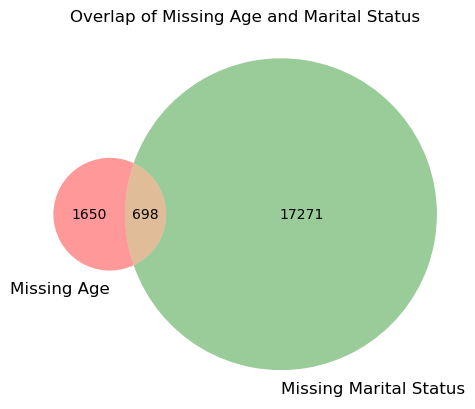

In [28]:
# visualize the overlap with a Venn diagram (requires matplotlib-venn)
from matplotlib_venn import venn2
venn2(subsets=(missing_age.sum(), missing_marital.sum(), overlap),
      set_labels=('Missing Age', 'Missing Marital Status'))
plt.title('Overlap of Missing Age and Marital Status')
plt.show()

### to see if missing age is related with any mental problem

In [8]:
vuln_cols = [
    'verified_vulnerability_cognitive_impairment',
    'verified_vulnerability_advanced_age_frailty_dependency',
    'verified_vulnerability_developmental_intellectual_disability',
    'verified_vulnerability_medically_fragile ',
    'verified_vulnerability_mental_illness'
]

print("--- Age Statistics by Vulnerability Status (Original Data) ---")
for col in vuln_cols:
    if col in df.columns:
        print(f"\n{col}:")
        display(df.groupby(col)['age_at_time_of_referral'].agg(['count', 'median', 'mean']).round(1))

print("\n" + "="*50 + "\n")

print("--- Vulnerability Status for Cases with MISSING Age ---")
missing_age_df = df[df['age_at_time_of_referral'].isna()]
for col in vuln_cols:
    if col in missing_age_df.columns:
        print(f"\n{col}:")
        display(missing_age_df[col].value_counts(dropna=False))


--- Age Statistics by Vulnerability Status (Original Data) ---

verified_vulnerability_cognitive_impairment:


,count,median,mean
verified_vulnerability_cognitive_impairment,,,
N,57938,69.0,65.5
Y,18936,73.0,67.4



verified_vulnerability_advanced_age_frailty_dependency:


,count,median,mean
verified_vulnerability_advanced_age_frailty_dependency,,,
N,48506,63.0,58.5
Y,28368,79.0,78.7



verified_vulnerability_developmental_intellectual_disability:


...

verified_vulnerability_advanced_age_frailty_dependency
N      890
Y      759
NaN      1
Name: count, dtype: int64


verified_vulnerability_developmental_intellectual_disability:


verified_vulnerability_developmental_intellectual_disability
N      1527
Y       122
NaN       1
Name: count, dtype: int64


verified_vulnerability_mental_illness:


verified_vulnerability_mental_illness
N      1465
Y       184
NaN       1
Name: count, dtype: int64

In [9]:
missing_age_df = df[df['age_at_time_of_referral'].isna()]

print("--- Percentage of 'Y' in Vulnerability Columns for Cases with MISSING Age ---")
for col in vuln_cols:
    if col in missing_age_df.columns:
        y_count = (missing_age_df[col] == 'Y').sum()
        total_count = len(missing_age_df)
        percentage = (y_count / total_count) * 100
        print(f"{col}: {percentage:.2f}% ({y_count}/{total_count})")


--- Percentage of 'Y' in Vulnerability Columns for Cases with MISSING Age ---
verified_vulnerability_cognitive_impairment: 26.55% (438/1650)
verified_vulnerability_advanced_age_frailty_dependency: 46.00% (759/1650)
verified_vulnerability_developmental_intellectual_disability: 7.39% (122/1650)
verified_vulnerability_mental_illness: 11.15% (184/1650)


In [10]:
vuln_cols = [
    'verified_vulnerability_cognitive_impairment',
    'verified_vulnerability_advanced_age_frailty_dependency',
    'verified_vulnerability_developmental_intellectual_disability',
    'verified_vulnerability_medically_fragile',
    'verified_vulnerability_mental_illness'
]

# Reset train/test split to ensure we are working with raw NaNs for age
train_df, test_df = train_test_split(survival_df, test_size=0.2, random_state=42)

# 1. Calculate the grouped medians on the TRAINING set
# We use dropna=False so that missing values in the vulnerability columns themselves are treated as a group
group_medians = train_df.groupby(vuln_cols, dropna=False)['age_at_time_of_referral'].median()

# Calculate the global training median as a fallback
global_median_age = train_df['age_at_time_of_referral'].median()

# 2. Define a function to apply the imputation
def impute_grouped_age(row, medians, global_median):
    if pd.isna(row['age_at_time_of_referral']):
        # Get the tuple of vulnerability values for this row
        group_key = tuple(row[col] for col in vuln_cols)
        # Return the specific group's median if it exists, else use the global median
        return medians.get(group_key, global_median)
    # If not missing, return the original age
    return row['age_at_time_of_referral']

# 3. Apply the function to both train and test datasets
train_df['age_at_time_of_referral'] = train_df.apply(
    lambda row: impute_grouped_age(row, group_medians, global_median_age), axis=1
)

test_df['age_at_time_of_referral'] = test_df.apply(
    lambda row: impute_grouped_age(row, group_medians, global_median_age), axis=1
)

# 4. Verify the results
print(f"Missing ages in train_df after grouped imputation: {train_df['age_at_time_of_referral'].isna().sum()}")
print(f"Missing ages in test_df after grouped imputation: {test_df['age_at_time_of_referral'].isna().sum()}")

# Let's peek at a few newly imputed rows in the training set
missing_age_mask = survival_df['age_at_time_of_referral'].isna()
train_missing_indices = train_df.index[train_df.index.isin(survival_df[missing_age_mask].index)]

print("\nSample of imputed ages (based on group):")
display(train_df.loc[train_missing_indices, vuln_cols + ['age_at_time_of_referral']].head())

Missing ages in train_df after grouped imputation: 0
Missing ages in test_df after grouped imputation: 0

Sample of imputed ages (based on group):


,verified_vulnerability_cognitive_impairment,verified_vulnerability_advanced_age_frailty_dependency,verified_vulnerability_developmental_intellectual_disability,verified_vulnerability_medically_fragile,verified_vulnerability_mental_illness,age_at_time_of_referral
38561,N,N,N,N,N,67.0
60161,N,Y,N,N,N,80.0
70810,N,N,N,N,N,67.0
25776,N,N,N,N,N,67.0
61295,N,N,N,Y,Y,62.0


In [11]:
cols_to_check = ['marital_status_description', 'does_client_live_alone', 'live_with_ind']

print("--- Missing Values in Training Set ---")
display(train_df[cols_to_check].isna().sum())

print("\n--- Value Counts (Including NaNs) in Training Set ---")
for col in cols_to_check:
    if col in train_df.columns:
        print(f"\n{col}:")
        display(train_df[col].value_counts(dropna=False))

--- Missing Values in Training Set ---


marital_status_description    13810
does_client_live_alone        15344
live_with_ind                   319
dtype: int64


--- Value Counts (Including NaNs) in Training Set ---

marital_status_description:


marital_status_description
Single-Never Married       21589
NaN                        13810
Widowed                    10693
Married-Living Together     8007
Divorced                    7025
Married-Separated           1636
Domestic Partner              80
Unknown                        7
Name: count, dtype: int64


does_client_live_alone:


does_client_live_alone
N      30285
Y      17218
NaN    15344
Name: count, dtype: int64


live_with_ind:


live_with_ind
N      50844
Y      11684
NaN      319
Name: count, dtype: int64

In [12]:
cols_to_fill_unknown = [
    'marital_status_description',
    'does_client_live_alone',
    'live_with_ind',
    'race',
    'primary_caregiver_ind',
    'perpetrator_type_desc'
]

for col in cols_to_fill_unknown:
    if col in train_df.columns:
        # Give a descriptive name for the missing category in 'does_client_live_alone'
        if col == 'does_client_live_alone':
            fill_val = 'Unknown_Facility_Homeless'
        else:
            fill_val = 'Unknown'

        train_df[col] = train_df[col].fillna(fill_val)
        test_df[col] = test_df[col].fillna(fill_val)

print("--- Missing Values in Training Set after Imputation ---")
display(train_df[cols_to_fill_unknown].isna().sum())

print("\n--- Value Counts for does_client_live_alone (Train) ---")
display(train_df['does_client_live_alone'].value_counts())

--- Missing Values in Training Set after Imputation ---


marital_status_description    0
does_client_live_alone        0
live_with_ind                 0
race                          0
primary_caregiver_ind         0
perpetrator_type_desc         0
dtype: int64


--- Value Counts for does_client_live_alone (Train) ---


does_client_live_alone
N                            30285
Y                            17218
Unknown_Facility_Homeless    15344
Name: count, dtype: int64

In [13]:
# Drop the remaining rows with missing values (approx 29 rows in train)
train_df = train_df.dropna()
test_df = test_df.dropna()

print(f"Final Training data shape: {train_df.shape}")
print(f"Final Testing data shape: {test_df.shape}")

# Verify that there are no more missing values
print(f"Max missing values in any column (Train): {train_df.isna().sum().max()}")
print(f"Max missing values in any column (Test): {test_df.isna().sum().max()}")

Final Training data shape: (62348, 95)
Final Testing data shape: (15569, 95)
Max missing values in any column (Train): 0
Max missing values in any column (Test): 0


In [14]:
# 1. Identify columns to drop (IDs and Dates)
cols_to_drop = ['id', 'person_id', 'referral_date', 'open_date', 'closed_date', 't0', 'end_of_obs']

# Keep the survival targets separate if needed, but for now we'll just drop the non-predictive stuff
X_train = train_df.drop(columns=cols_to_drop, errors='ignore')
X_test = test_df.drop(columns=cols_to_drop, errors='ignore')

# 2. Identify categorical columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode: {len(cat_cols)}\n")

# 3. Apply One-Hot Encoding
# drop_first=True avoids the dummy variable trap by dropping one category per column
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True, dtype=int)

# 4. Align the train and test sets to ensure they have the exact same columns
# (in case some categories were only present in the training or test set)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print(f"Encoded Training data shape: {X_train_encoded.shape}")
print(f"Encoded Testing data shape: {X_test_encoded.shape}")

# Display the first few columns to verify
X_train_encoded.head()

Categorical columns to encode: 82

Encoded Training data shape: (62348, 303)
Encoded Testing data shape: (15569, 303)


,number_of_days_open,age_at_time_of_referral,total_case_count,case_order,event_next,stop_time,prior_aps_history_before_2022_Y,gender_M,gender_O,gender_U,...,perpetrator_intial_risk_financial_dependency_2,perpetrator_intial_risk_financial_dependency_3,perpetrator_intial_risk_financial_dependency_4,perpetrator_intial_risk_financial_dependency_I,perpetrator_intial_risk_financial_dependency_N,perpetrator_intial_risk_mental_emotional_health_control_over_client_2,perpetrator_intial_risk_mental_emotional_health_control_over_client_3,perpetrator_intial_risk_mental_emotional_health_control_over_client_4,perpetrator_intial_risk_mental_emotional_health_control_over_client_I,perpetrator_intial_risk_mental_emotional_health_control_over_client_N
57543,62.0,65.0,3,1,1,0.0,0,1,0,0,...,1,0,0,0,0,1,0,0,0,0
4818,46.0,54.0,2,1,1,33.0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
52157,75.0,20.0,6,1,0,1095.0,0,1,0,0,...,0,0,1,0,0,0,1,0,0,0
6675,107.0,34.0,2,1,1,749.0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
8725,21.0,31.0,1,1,0,1096.0,0,1,0,0,...,1,0,0,0,0,1,0,0,0,0


In [15]:
survival_df['event_next'].sum() / len(survival_df)

0.32765182856197256

## MODEL TRAINING

### Training Dummy

In [16]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Separate the target (y) and drop leakage columns from the features (X)
y_train = X_train_encoded['event_next']
y_test = X_test_encoded['event_next']

# Drop both the target and the leaking stop_time column from the training data
X_train_model = X_train_encoded.drop(columns=['event_next', 'stop_time'], errors='ignore')
X_test_model = X_test_encoded.drop(columns=['event_next', 'stop_time'], errors='ignore')

print(f"Final Features shape: {X_train_model.shape}")

# 2. Initialize and train the Dummy Naive Model
# strategy="prior" always predicts the most frequent class in the training set (which is 0)
dummy_clf = DummyClassifier(strategy="prior")
dummy_clf.fit(X_train_model, y_train)

# 3. Make predictions on the test set
y_pred = dummy_clf.predict(X_test_model)

# 4. Evaluate the baseline performance
print("\n--- Dummy Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Final Features shape: (62348, 301)

--- Dummy Model Performance ---
Accuracy: 0.6693

Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80     10420
           1       0.00      0.00      0.00      5149

    accuracy                           0.67     15569
   macro avg       0.33      0.50      0.40     15569
weighted avg       0.45      0.67      0.54     15569



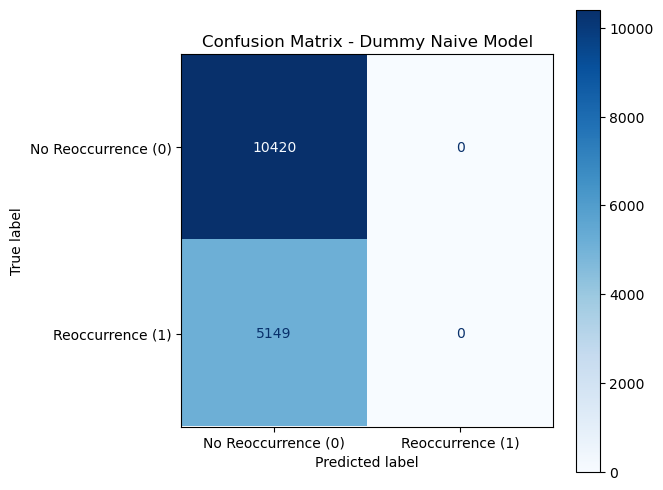

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Reoccurrence (0)', 'Reoccurrence (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title('Confusion Matrix - Dummy Naive Model')
plt.grid(False)
plt.show()

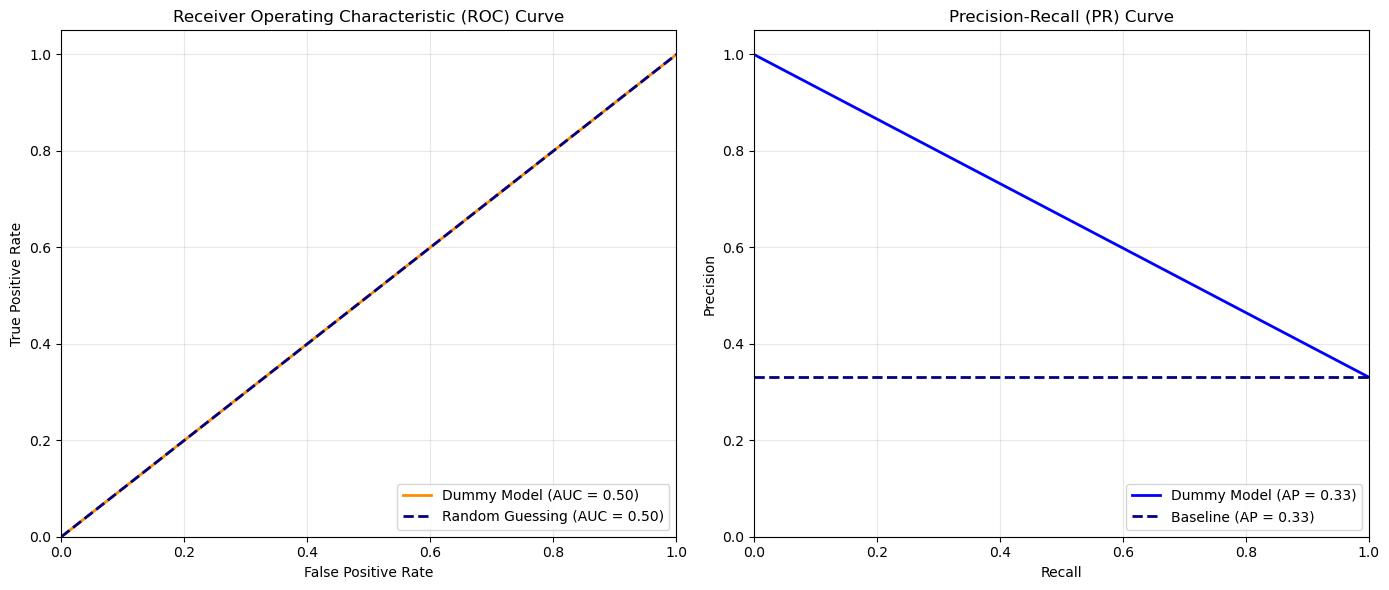

ROC-AUC Score: 0.5000
Average Precision (PR-AUC) Score: 0.3307


In [18]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_probs = dummy_clf.predict_proba(X_test_model)[:, 1]

# Calculate scores
roc_auc = roc_auc_score(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)

# Calculate curve points
fpr, tpr, roc_thresholds = roc_curve(y_test, y_probs)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_probs)

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. ROC Curve
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'Dummy Model (AUC = {roc_auc:.2f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.50)')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('Receiver Operating Characteristic (ROC) Curve')
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.3)

# 2. Precision-Recall Curve
baseline = len(y_test[y_test == 1]) / len(y_test)
ax[1].plot(recall, precision, color='blue', lw=2, label=f'Dummy Model (AP = {ap_score:.2f})')
ax[1].axhline(y=baseline, color='navy', lw=2, linestyle='--', label=f'Baseline (AP = {baseline:.2f})')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall (PR) Curve')
ax[1].legend(loc="lower right")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Average Precision (PR-AUC) Score: {ap_score:.4f}")

### Clean Logistic Regression Model
First, we will ensure that data leakage features (`total_case_count`, `case_order`) are removed. Then, we will standardize the features and train the Logistic Regression model.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Drop leaking columns to prevent unfair advantage
leakage_cols = ['total_case_count', 'case_order']
X_train_clean = X_train_model.drop(columns=leakage_cols, errors='ignore')
X_test_clean = X_test_model.drop(columns=leakage_cols, errors='ignore')

print(f"Number of features after removing leakage: {X_train_clean.shape[1]}")

# 2. Feature Scaling
scaler = StandardScaler()
# Fit the scaler only on the training data, then transform both
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

# 3. Initialize and Train Logistic Regression
# max_iter=1000 ensures convergence
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Number of features after removing leakage: 299
Logistic Regression model trained successfully!


### Evaluate Logistic Regression
Let's evaluate the model's performance on the test set using Accuracy, ROC-AUC, and the Confusion Matrix.

--- Logistic Regression Performance ---
Accuracy: 0.6910

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.88      0.79     10420
           1       0.56      0.30      0.39      5149

    accuracy                           0.69     15569
   macro avg       0.64      0.59      0.59     15569
weighted avg       0.67      0.69      0.66     15569

ROC-AUC Score: 0.7005
Average Precision (PR-AUC): 0.5113


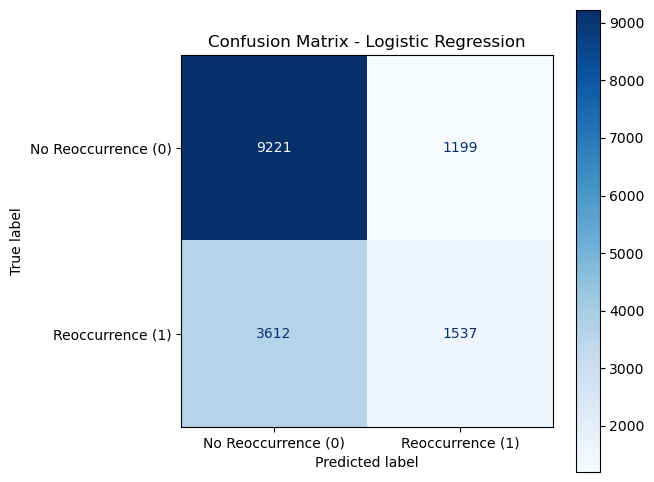

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = log_reg.predict(X_test_scaled)
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

# Basic Metrics
print("--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Average Precision (PR-AUC): {ap_score:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                 display_labels=['No Reoccurrence (0)', 'Reoccurrence (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.grid(False)
plt.show()

### Feature Importance (Logistic Regression Coefficients)
Let's extract the coefficients to see which features most strongly influence the model's prediction. Positive values indicate a higher likelihood of case reoccurrence, while negative values indicate a lower likelihood.

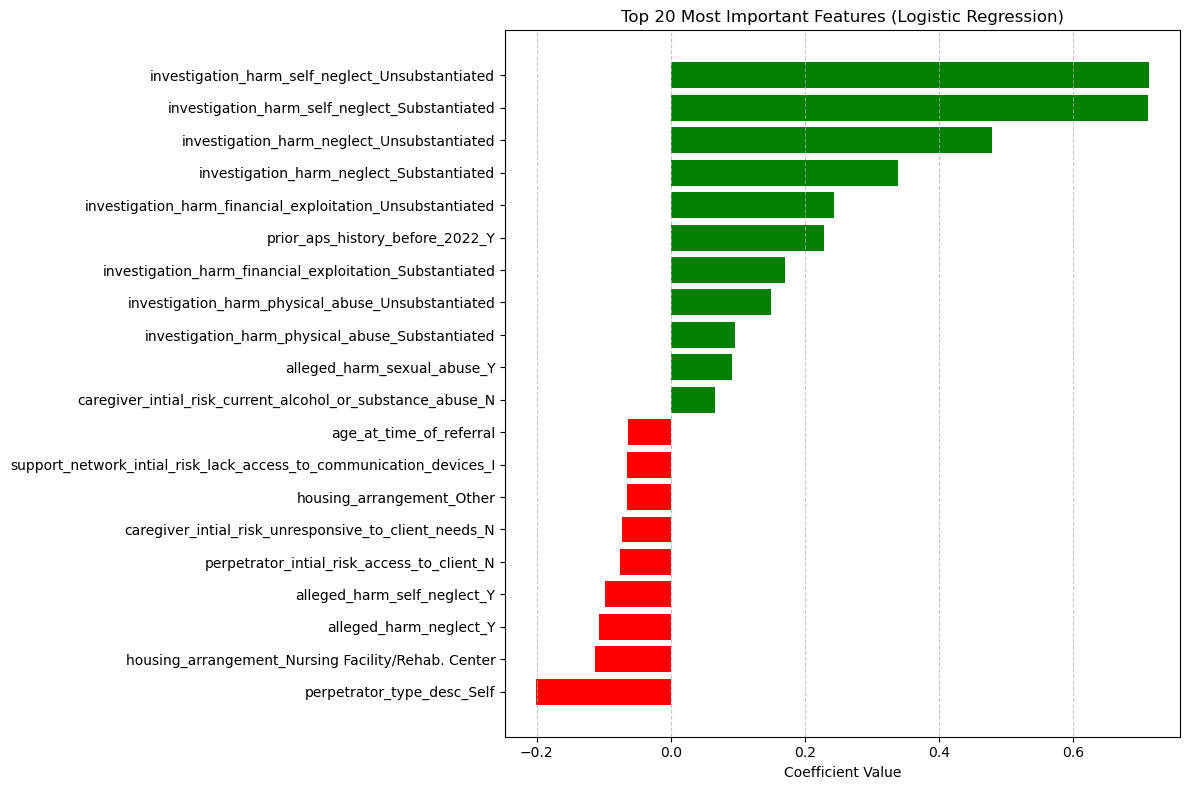

In [21]:
import pandas as pd
import numpy as np

# Get feature names and coefficients
feature_names = X_train_clean.columns
coefficients = log_reg.coef_[0]

# Create a DataFrame for easy sorting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

# Get the top 20 most important features (by absolute magnitude)
top_features = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)

# Sort again by actual coefficient value for a cleaner plot
top_features = top_features.sort_values(by='Coefficient', ascending=True)

# Plot
plt.figure(figsize=(12, 8))
colors = ['red' if c < 0 else 'green' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Top 20 Most Important Features (Logistic Regression)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Train Random Forest Classifier
Tree-based models like Random Forest do not require feature scaling, so we can train it directly on the clean, unscaled dataset (`X_train_clean`).

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and Train Random Forest
# n_jobs=-1 uses all available CPU cores to speed up training
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_clean, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


### Evaluate Random Forest

--- Random Forest Performance ---
Accuracy: 0.5969

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.79      0.71      6293
           1       0.46      0.28      0.35      3890

    accuracy                           0.60     10183
   macro avg       0.55      0.54      0.53     10183
weighted avg       0.57      0.60      0.57     10183

ROC-AUC Score: 0.5858
Average Precision (PR-AUC): 0.4459


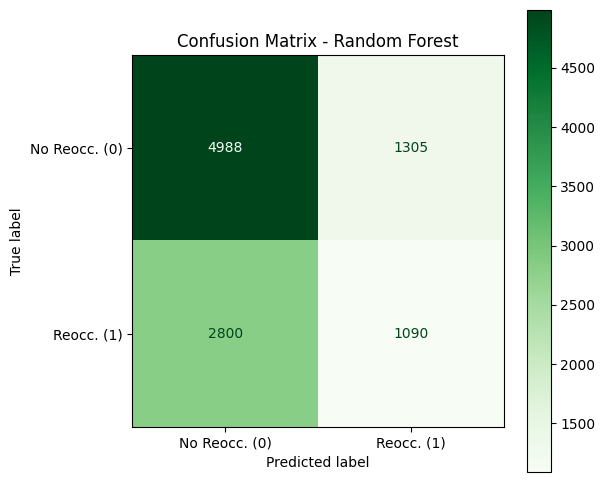

In [ ]:
# Predict on the test set using the unscaled test data
y_pred_rf = rf_clf.predict(X_test_clean)
y_probs_rf = rf_clf.predict_proba(X_test_clean)[:, 1]

# Basic Metrics
print("--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_probs_rf)
ap_score_rf = average_precision_score(y_test, y_probs_rf)
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")
print(f"Average Precision (PR-AUC): {ap_score_rf:.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                 display_labels=['No Reocc. (0)', 'Reocc. (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_rf.plot(cmap=plt.cm.Greens, ax=ax, values_format='d')
plt.title('Confusion Matrix - Random Forest')
plt.grid(False)
plt.show()

### Feature Importance (Random Forest)
Unlike Logistic Regression coefficients which can be positive or negative, Random Forest feature importances (Gini importance) are strictly positive and indicate how useful a feature was for splitting the data across all trees.

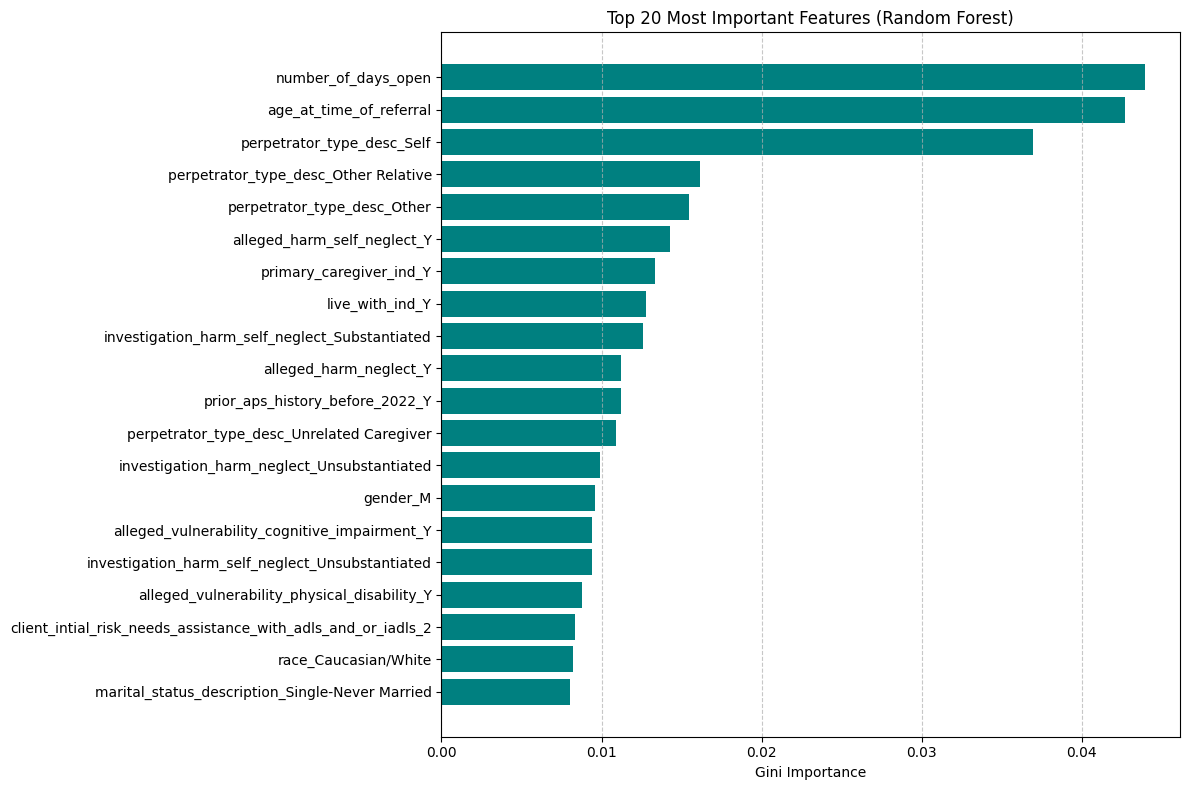

In [ ]:
# Extract feature importances
rf_importances = rf_clf.feature_importances_

# Create a DataFrame for easy sorting
rf_coef_df = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False).head(20)

# Sort ascending for plotting
rf_coef_df = rf_coef_df.sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(12, 8))
plt.barh(rf_coef_df['Feature'], rf_coef_df['Importance'], color='teal')
plt.xlabel('Gini Importance')
plt.title('Top 20 Most Important Features (Random Forest)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Balanced Random Forest (max_depth=5) model trained successfully!

--- Balanced Random Forest (max_depth=5) Performance ---
Accuracy: 0.6319

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.65      0.69      6293
           1       0.52      0.61      0.56      3890

    accuracy                           0.63     10183
   macro avg       0.62      0.63      0.62     10183
weighted avg       0.65      0.63      0.64     10183

ROC-AUC Score: 0.6720
Average Precision (PR-AUC): 0.5495


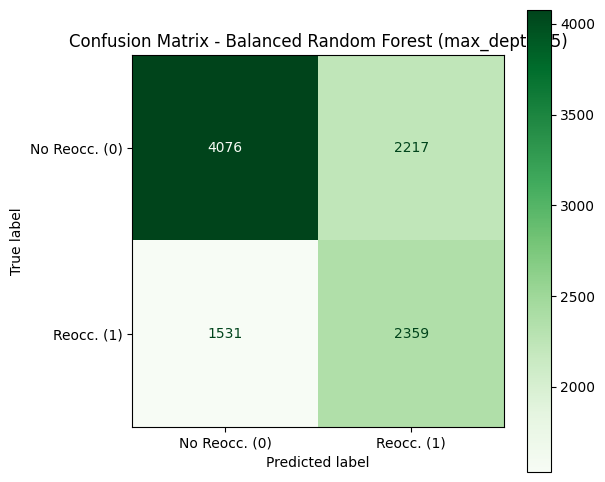

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Train with class_weight='balanced' and max_depth=5
# We must use X_train_clean to avoid data leakage and use properly encoded features
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train_clean, y_train)
print("Balanced Random Forest (max_depth=5) model trained successfully!\n")

# 2. Evaluate on the test set
y_pred_rf_bal = rf_model.predict(X_test_clean)
y_probs_rf_bal = rf_model.predict_proba(X_test_clean)[:, 1]

print("--- Balanced Random Forest (max_depth=5) Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_bal):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_bal))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs_rf_bal):.4f}")
print(f"Average Precision (PR-AUC): {average_precision_score(y_test, y_probs_rf_bal):.4f}")

# 3. Confusion Matrix
cm_rf_bal = confusion_matrix(y_test, y_pred_rf_bal)
disp_rf_bal = ConfusionMatrixDisplay(confusion_matrix=cm_rf_bal,
                                     display_labels=['No Reocc. (0)', 'Reocc. (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
disp_rf_bal.plot(cmap=plt.cm.Greens, ax=ax, values_format='d')
plt.title('Confusion Matrix - Balanced Random Forest (max_depth=5)')
plt.grid(False)
plt.show()


### Train XGBoost Classifier
XGBoost is a powerful gradient boosting algorithm that often performs exceptionally well on tabular data. We will use `scale_pos_weight` to handle our class imbalance.

In [ ]:
import xgboost as xgb

# Calculate the ratio of negative to positive instances for scale_pos_weight
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
scale_weight = neg_class_count / pos_class_count

# Initialize and Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(X_train_clean, y_train)
print("XGBoost model trained successfully!")

XGBoost model trained successfully!


### Evaluate XGBoost

--- XGBoost Performance ---
Accuracy: 0.6601

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.70      0.72      6293
           1       0.55      0.59      0.57      3890

    accuracy                           0.66     10183
   macro avg       0.64      0.65      0.64     10183
weighted avg       0.66      0.66      0.66     10183

ROC-AUC Score: 0.6885
Average Precision (PR-AUC): 0.5491


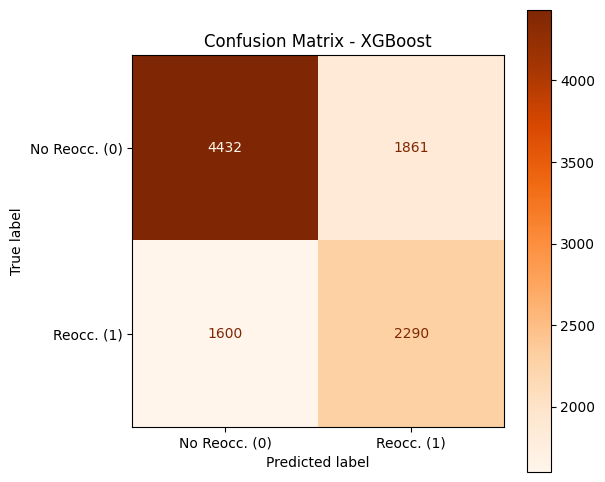

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test_clean)
y_probs_xgb = xgb_model.predict_proba(X_test_clean)[:, 1]

# Basic Metrics
print("--- XGBoost Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

roc_auc_xgb = roc_auc_score(y_test, y_probs_xgb)
ap_score_xgb = average_precision_score(y_test, y_probs_xgb)
print(f"ROC-AUC Score: {roc_auc_xgb:.4f}")
print(f"Average Precision (PR-AUC): {ap_score_xgb:.4f}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
                                 display_labels=['No Reocc. (0)', 'Reocc. (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_xgb.plot(cmap=plt.cm.Oranges, ax=ax, values_format='d')
plt.title('Confusion Matrix - XGBoost')
plt.grid(False)
plt.show()

### Feature Importance (XGBoost)
Let's see which features XGBoost found most useful.

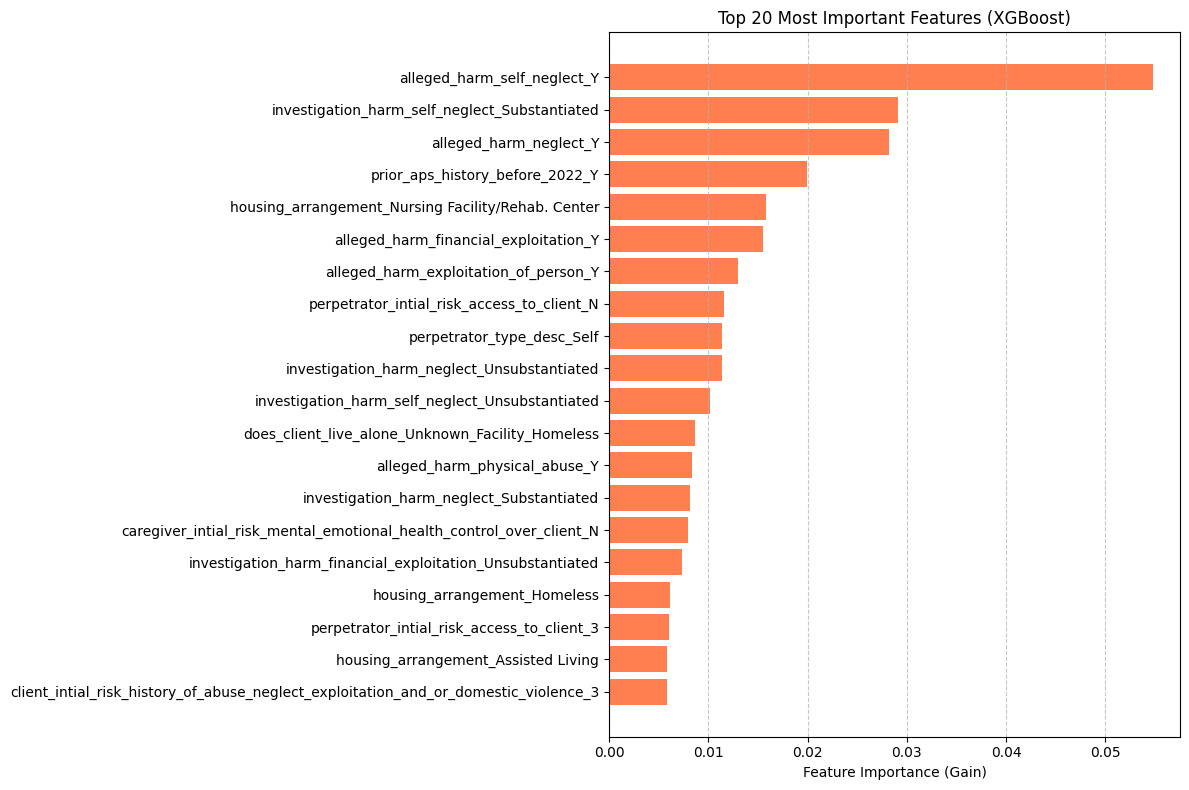

In [ ]:
import pandas as pd

# Extract feature importances
xgb_importances = xgb_model.feature_importances_

# Create a DataFrame for easy sorting
xgb_coef_df = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'Importance': xgb_importances
}).sort_values(by='Importance', ascending=False).head(20)

# Sort ascending for plotting
xgb_coef_df = xgb_coef_df.sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(12, 8))
plt.barh(xgb_coef_df['Feature'], xgb_coef_df['Importance'], color='coral')
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 20 Most Important Features (XGBoost)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Hyperparameter Tuning (XGBoost)
We will use `GridSearchCV` to find a better set of hyperparameters for our XGBoost model to improve performance.

In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Calculate the ratio of negative to positive instances for scale_pos_weight
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
scale_weight = neg_class_count / pos_class_count

# Define the base model
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# Define the parameter grid to search
# Reduced grid size for faster execution
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc', # Optimize for ROC-AUC given our imbalanced classes
    cv=3,              # 3-fold cross-validation
    verbose=1,
    n_jobs=-1
)

print("Starting Grid Search...")
# Fit the grid search to the data
grid_search.fit(X_train_clean, y_train)

print("Grid Search completed!")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best ROC-AUC score from CV: {grid_search.best_score_:.4f}")

# Retrieve the best model
best_xgb_model = grid_search.best_estimator_

Starting Grid Search...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Grid Search completed!
Best parameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best ROC-AUC score from CV: 0.6949


### Evaluate Best XGBoost Model
Let's see how the tuned model performs on the holdout test set.

--- Tuned XGBoost Performance ---
Accuracy: 0.6562

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.70      0.71      6293
           1       0.55      0.59      0.57      3890

    accuracy                           0.66     10183
   macro avg       0.64      0.64      0.64     10183
weighted avg       0.66      0.66      0.66     10183

ROC-AUC Score: 0.6917
Average Precision (PR-AUC): 0.5567


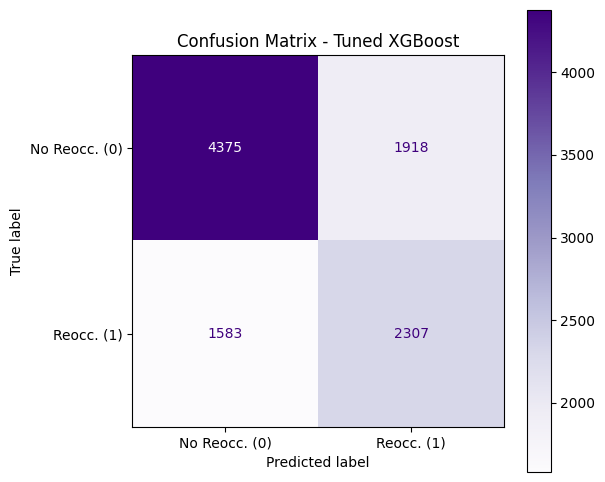

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on the test set using the best model
y_pred_best_xgb = best_xgb_model.predict(X_test_clean)
y_probs_best_xgb = best_xgb_model.predict_proba(X_test_clean)[:, 1]

# Basic Metrics
print("--- Tuned XGBoost Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_xgb))

roc_auc_best_xgb = roc_auc_score(y_test, y_probs_best_xgb)
ap_score_best_xgb = average_precision_score(y_test, y_probs_best_xgb)
print(f"ROC-AUC Score: {roc_auc_best_xgb:.4f}")
print(f"Average Precision (PR-AUC): {ap_score_best_xgb:.4f}")

# Confusion Matrix
cm_best_xgb = confusion_matrix(y_test, y_pred_best_xgb)
disp_best_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_best_xgb,
                                 display_labels=['No Reocc. (0)', 'Reocc. (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_best_xgb.plot(cmap=plt.cm.Purples, ax=ax, values_format='d')
plt.title('Confusion Matrix - Tuned XGBoost')
plt.grid(False)
plt.show()

In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 16.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=99a5bfcbbec97596645e1fbefbec9ace9277f20741d1879cbaa9e7760c1f2521
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


### Train Cox Proportional Hazards Model
Survival models like CoxPH require the `duration` (stop_time) and `event` (event_next) to be included in the dataset used for fitting.

In [ ]:
from lifelines import CoxPHFitter

# 1. Prepare the data for lifelines
# We need the features + duration + event in a single DataFrame
train_cox = X_train_clean.copy()
train_cox['stop_time'] = X_train_encoded['stop_time']
train_cox['event_next'] = y_train

test_cox = X_test_clean.copy()
test_cox['stop_time'] = X_test_encoded['stop_time']
test_cox['event_next'] = y_test

# 2. Initialize the CoxPHFitter
# We add a penalizer because fitting 300 features can cause convergence and collinearity issues
cph = CoxPHFitter(penalizer=0.1)

# 3. Fit the model
print("Fitting Cox Proportional Hazards model...")
cph.fit(train_cox, duration_col='stop_time', event_col='event_next')
print("Model fitted successfully!\n")

# 4. Evaluate using Concordance Index (C-index)
train_c_index = cph.score(train_cox, scoring_method='concordance_index')
test_c_index = cph.score(test_cox, scoring_method='concordance_index')

print(f"Train Concordance Index: {train_c_index:.4f}")
print(f"Test Concordance Index: {test_c_index:.4f}")

Fitting Cox Proportional Hazards model...


/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['gender_O'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


Model fitted successfully!

Train Concordance Index: 0.6697
Test Concordance Index: 0.6568


### Survival Curves by Risk Group
We will use the fitted Cox model to predict the relative risk for each case in the test set, split the data into tertiles (Low, Medium, High Risk), and plot their actual survival probabilities over time using a Kaplan-Meier estimator.

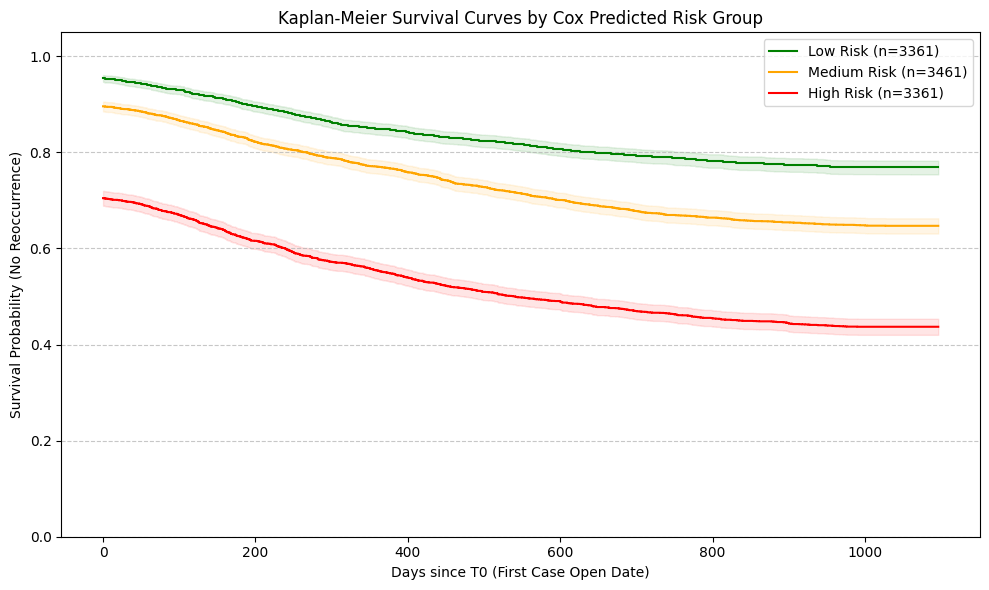

In [ ]:
from lifelines import KaplanMeierFitter
import numpy as np
import matplotlib.pyplot as plt

# 1. Predict risk scores (partial hazard) on the test set
test_cox['risk_score'] = cph.predict_partial_hazard(test_cox)

# 2. Define risk groups based on quantiles (tertiles)
low_thresh = test_cox['risk_score'].quantile(0.33)
high_thresh = test_cox['risk_score'].quantile(0.67)

conditions = [
    (test_cox['risk_score'] <= low_thresh),
    (test_cox['risk_score'] > low_thresh) & (test_cox['risk_score'] <= high_thresh),
    (test_cox['risk_score'] > high_thresh)
]
choices = ['Low Risk', 'Medium Risk', 'High Risk']
# Explicitly set a string default to avoid dtype promotion errors
test_cox['risk_group'] = np.select(conditions, choices, default='Unknown')

# 3. Plot Kaplan-Meier survival curves for each group
plt.figure(figsize=(10, 6))
kmf = KaplanMeierFitter()

colors = {'Low Risk': 'green', 'Medium Risk': 'orange', 'High Risk': 'red'}

for group in ['Low Risk', 'Medium Risk', 'High Risk']:
    mask = test_cox['risk_group'] == group
    kmf.fit(
        durations=test_cox['stop_time'][mask],
        event_observed=test_cox['event_next'][mask],
        label=f'{group} (n={mask.sum()})'
    )
    kmf.plot_survival_function(color=colors[group], ci_alpha=0.1)

plt.title('Kaplan-Meier Survival Curves by Cox Predicted Risk Group')
plt.xlabel('Days since T0 (First Case Open Date)')
plt.ylabel('Survival Probability (No Reoccurrence)')
plt.ylim([0.0, 1.05])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Cox Proportional Hazards Coefficients (Hazard Ratios)
Let's extract the coefficients from the Cox model.
* **`coef` (Log Hazard Ratio):** A positive value means higher risk of reoccurrence (shorter survival time). A negative value means lower risk.
* **`exp(coef)` (Hazard Ratio):** A value > 1 means increased risk, < 1 means decreased risk.

--- Top 20 Most Impactful Features (CoxPH) ---


,coef,exp(coef),p,z
covariate,,,,
race_Alaskan Native,-0.628144,0.533581,3.413246e-01,-0.951551
gender_U,-0.592021,0.553208,2.179761e-03,-3.064580
investigation_harm_self_neglect_Substantiated,0.434981,1.544934,2.863775e-90,20.146922
investigation_harm_self_neglect_Unsubstantiated,0.424006,1.528070,1.087521e-81,19.143929
perpetrator_type_desc_Parent,-0.398165,0.671551,1.439743e-04,-3.801239
race_Two or more races,-0.388988,0.677742,2.664572e-01,-1.111258
perpetrator_type_desc_Paid Caregiver,-0.370752,0.690215,1.214745e-02,-2.507832
perpetrator_type_desc_Residential Staff,-0.285580,0.751578,3.172934e-02,-2.147804
investigation_harm_neglect_Substantiated,0.284401,1.328966,7.309056e-25,10.296475


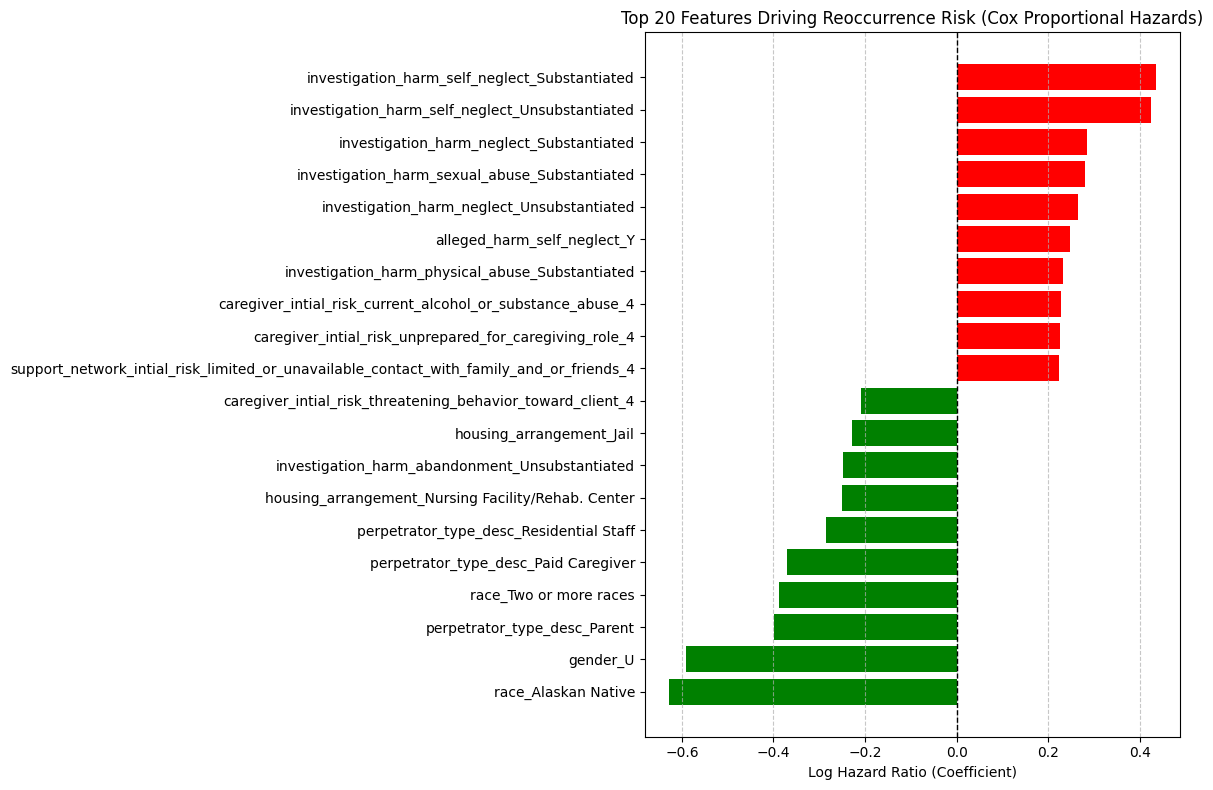

In [ ]:
import matplotlib.pyplot as plt

# 1. Extract the summary dataframe from the fitted Cox model
cph_summary = cph.summary[['coef', 'exp(coef)', 'p', 'z']].copy()

# 2. Add an absolute coefficient column to find the most impactful features (both positive and negative)
cph_summary['abs_coef'] = cph_summary['coef'].abs()

# 3. Get the top 20 most impactful features
top_cox_features = cph_summary.sort_values(by='abs_coef', ascending=False).head(20)

print("--- Top 20 Most Impactful Features (CoxPH) ---")
display(top_cox_features.drop(columns=['abs_coef']))

# 4. Plot the top 20 features
plt.figure(figsize=(12, 8))
# Sort by actual coefficient value for a cleaner plot
top_cox_plot = top_cox_features.sort_values(by='coef', ascending=True)

# Red for increased risk (positive coef), Green for decreased risk (negative coef)
colors = ['red' if c > 0 else 'green' for c in top_cox_plot['coef']]

plt.barh(top_cox_plot.index, top_cox_plot['coef'], color=colors)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Log Hazard Ratio (Coefficient)')
plt.title('Top 20 Features Driving Reoccurrence Risk (Cox Proportional Hazards)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Prepare Model for Deployment
We will serialize the final `best_xgb_model` and save the exact feature columns it expects. This ensures that when the model is deployed, the preprocessing pipeline can align incoming data to the correct format.

In [ ]:
import joblib
import json

# 1. Save the XGBoost model using joblib
model_filename = 'best_aps_xgb_model.joblib'
joblib.dump(best_xgb_model, model_filename)
print(f"Model saved successfully to {model_filename}")

# 2. Save the expected feature names
# This is crucial for deployment to ensure the incoming data has the exact same One-Hot Encoded columns
feature_names = X_train_clean.columns.tolist()
features_filename = 'aps_model_features.json'
with open(features_filename, 'w') as f:
    json.dump(feature_names, f)
print(f"Feature names saved successfully to {features_filename}")
